Saving archive (1).zip to archive (1).zip


/tmp/ipykernel_1168/197665803.py:87: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


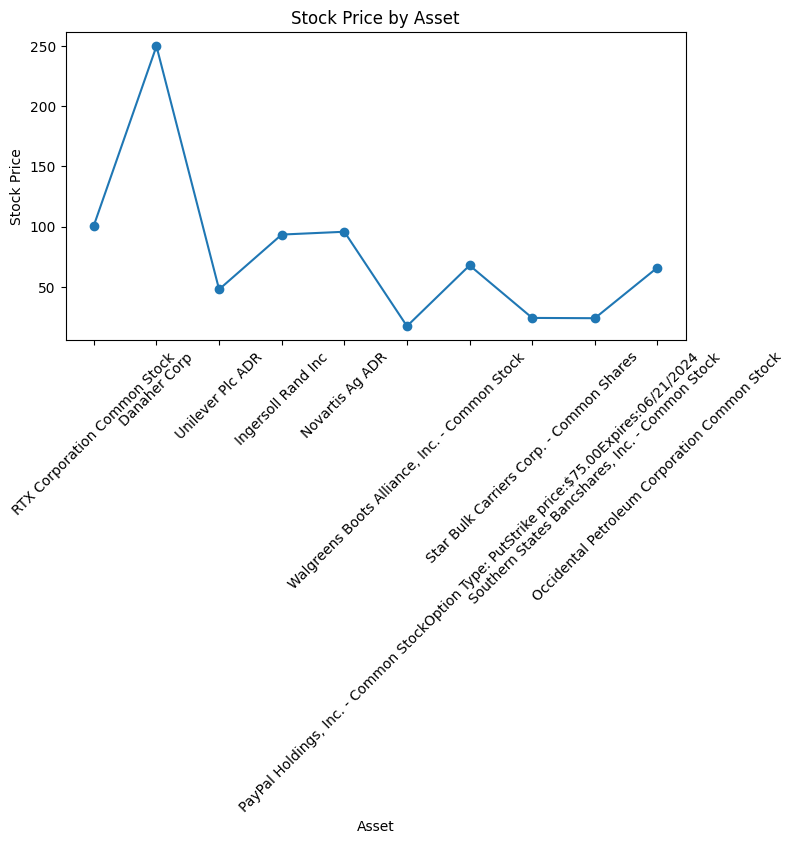

/tmp/ipykernel_1168/197665803.py:108: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


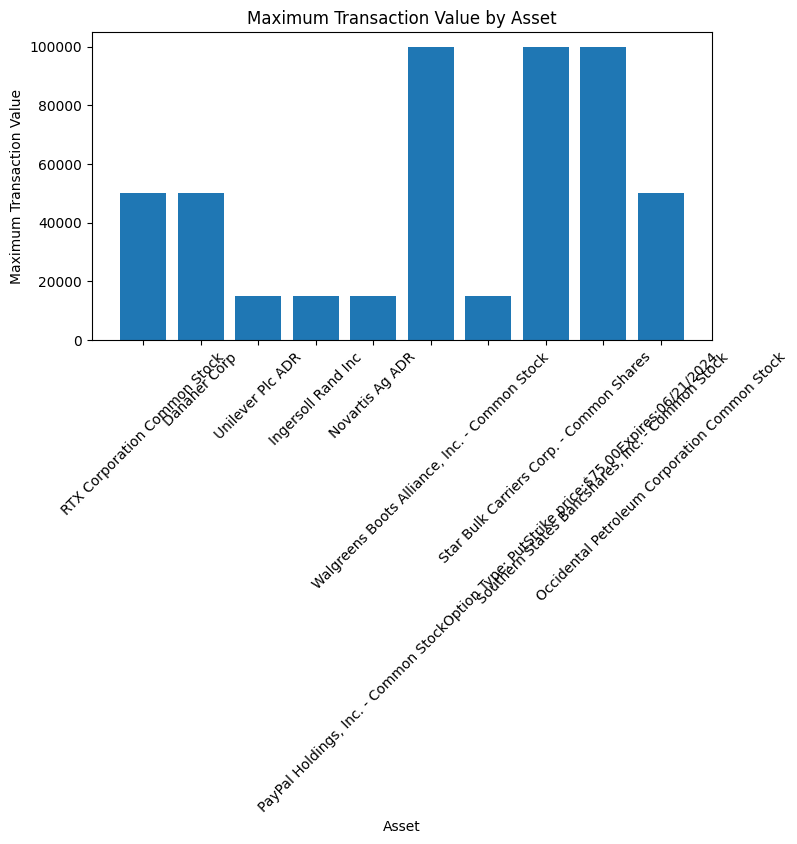

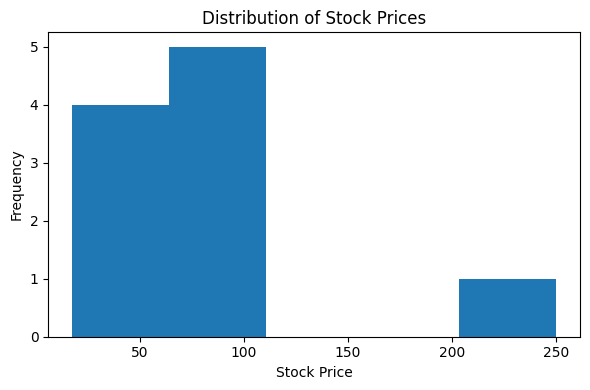

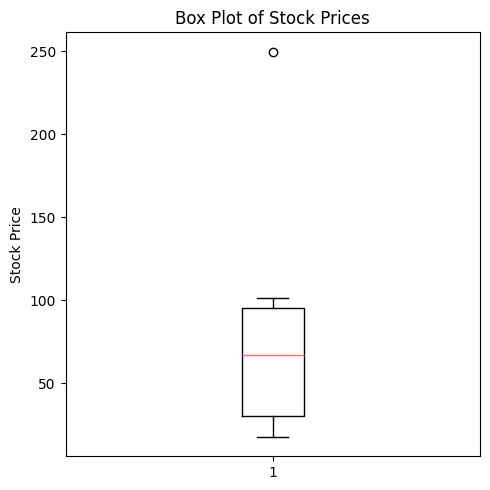

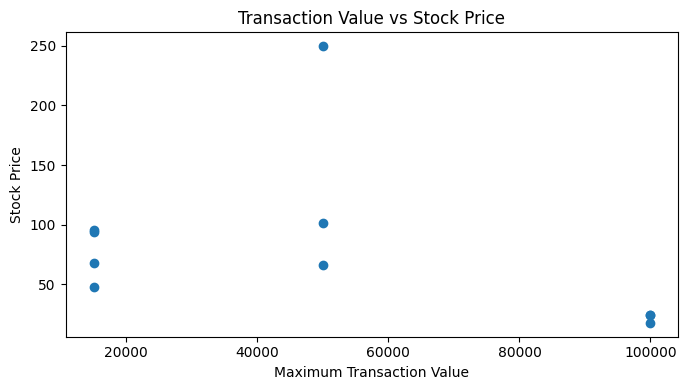

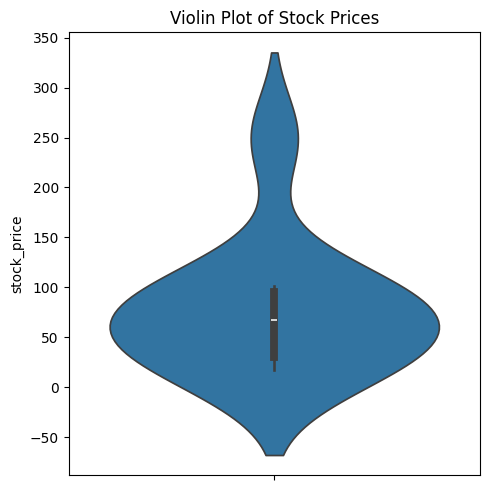

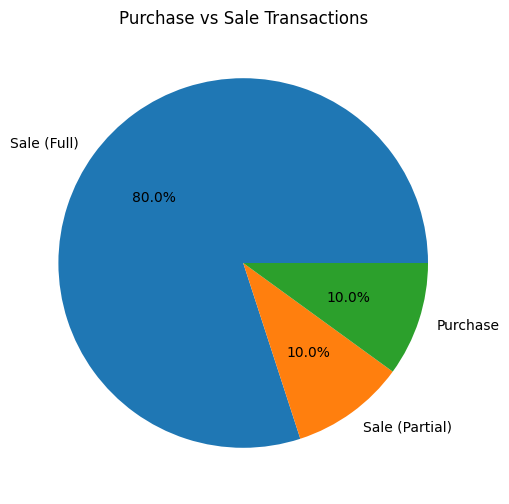

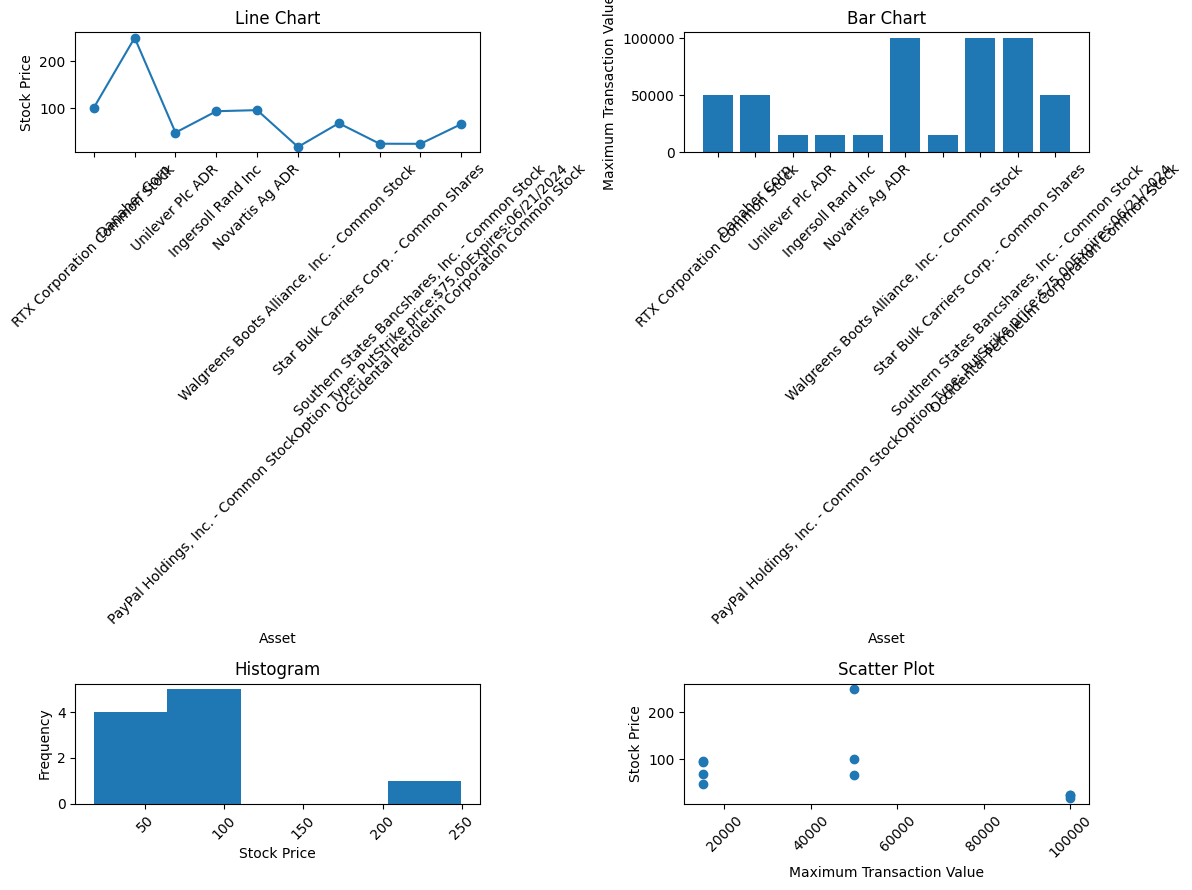

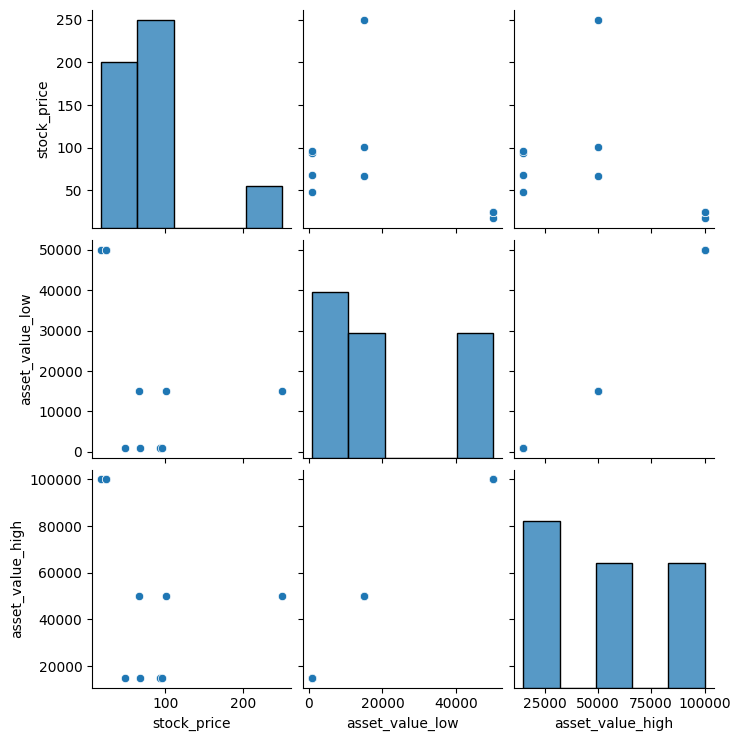

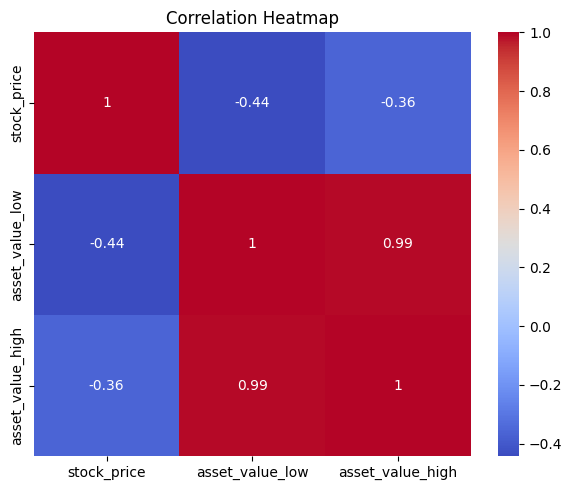

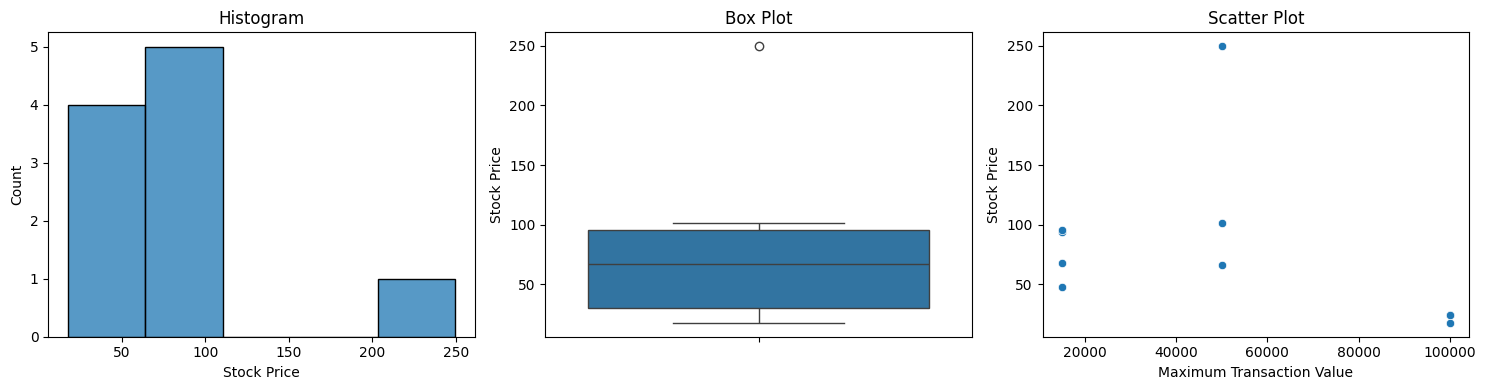

In [2]:
# Install seaborn
%pip install seaborn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------------

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# Read first 10 rows, matching the reference experiment
df = df.head(10).copy()

# ---------------------------------------------------------
# CONVERT NUMERIC / DATE COLUMNS
# ---------------------------------------------------------

df["stock_price"] = pd.to_numeric(
    df["stock_price"],
    errors="coerce"
)

df["asset_value_low"] = pd.to_numeric(
    df["asset_value_low"],
    errors="coerce"
)

df["asset_value_high"] = pd.to_numeric(
    df["asset_value_high"],
    errors="coerce"
)

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

# Create a senator name column
df["senator"] = (
    df["first_name"].fillna("") + " " +
    df["last_name"].fillna("")
).str.strip()

# ---------------------------------------------------------
# NUMERIC COLUMNS USED FOR ANALYSIS
# ---------------------------------------------------------

cols = [
    "stock_price",
    "asset_value_low",
    "asset_value_high"
]

# ---------------------------------------------------------
# X-AXIS
# ---------------------------------------------------------

x = df["asset_name"].fillna("Unknown Asset")


# =========================================================
# 1. LINE CHART
# =========================================================

plt.figure(figsize=(8, 4))

plt.plot(
    x,
    df["stock_price"],
    marker="o"
)

plt.title("Stock Price by Asset")
plt.xlabel("Asset")
plt.ylabel("Stock Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# =========================================================
# 2. BAR CHART
# =========================================================

plt.figure(figsize=(8, 4))

plt.bar(
    x,
    df["asset_value_high"]
)

plt.title("Maximum Transaction Value by Asset")
plt.xlabel("Asset")
plt.ylabel("Maximum Transaction Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# =========================================================
# 3. HISTOGRAM
# =========================================================

plt.figure(figsize=(6, 4))

plt.hist(
    df["stock_price"].dropna(),
    bins=5
)

plt.title("Distribution of Stock Prices")
plt.xlabel("Stock Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# =========================================================
# 4. BOX PLOT
# =========================================================

plt.figure(figsize=(5, 5))

plt.boxplot(
    df["stock_price"].dropna()
)

plt.title("Box Plot of Stock Prices")
plt.ylabel("Stock Price")

plt.tight_layout()
plt.show()


# =========================================================
# 5. SCATTER PLOT
# =========================================================

plt.figure(figsize=(7, 4))

plt.scatter(
    df["asset_value_high"],
    df["stock_price"]
)

plt.xlabel("Maximum Transaction Value")
plt.ylabel("Stock Price")
plt.title("Transaction Value vs Stock Price")

plt.tight_layout()
plt.show()


# =========================================================
# 6. VIOLIN PLOT
# =========================================================

plt.figure(figsize=(5, 5))

sns.violinplot(
    y=df["stock_price"].dropna()
)

plt.title("Violin Plot of Stock Prices")

plt.tight_layout()
plt.show()


# =========================================================
# 7. PIE CHART
# =========================================================

transaction_counts = df["transaction"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    transaction_counts.values,
    labels=transaction_counts.index,
    autopct="%1.1f%%"
)

plt.title("Purchase vs Sale Transactions")

plt.show()


# =========================================================
# 8. SUBPLOTS (2 x 2)
# =========================================================

fig, ax = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

# Line
ax[0, 0].plot(
    x,
    df["stock_price"],
    marker="o"
)

ax[0, 0].set_title("Line Chart")
ax[0, 0].set_xlabel("Asset")
ax[0, 0].set_ylabel("Stock Price")


# Bar
ax[0, 1].bar(
    x,
    df["asset_value_high"]
)

ax[0, 1].set_title("Bar Chart")
ax[0, 1].set_xlabel("Asset")
ax[0, 1].set_ylabel("Maximum Transaction Value")


# Histogram
ax[1, 0].hist(
    df["stock_price"].dropna(),
    bins=5
)

ax[1, 0].set_title("Histogram")
ax[1, 0].set_xlabel("Stock Price")
ax[1, 0].set_ylabel("Frequency")


# Scatter
ax[1, 1].scatter(
    df["asset_value_high"],
    df["stock_price"]
)

ax[1, 1].set_title("Scatter Plot")
ax[1, 1].set_xlabel("Maximum Transaction Value")
ax[1, 1].set_ylabel("Stock Price")


for a in ax.flat:
    a.tick_params(
        axis="x",
        rotation=45
    )

plt.tight_layout()
plt.show()


# =========================================================
# 9. PAIR PLOT
# =========================================================

sns.pairplot(
    df[cols]
)

plt.show()


# =========================================================
# 10. HEATMAP
# =========================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


# =========================================================
# 11. SEABORN 3-PANEL PLOT
# =========================================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)


# Histogram
sns.histplot(
    df["stock_price"],
    ax=ax[0]
)

ax[0].set_title("Histogram")
ax[0].set_xlabel("Stock Price")


# Box Plot
sns.boxplot(
    y=df["stock_price"],
    ax=ax[1]
)

ax[1].set_title("Box Plot")
ax[1].set_ylabel("Stock Price")


# Scatter Plot
sns.scatterplot(
    x=df["asset_value_high"],
    y=df["stock_price"],
    ax=ax[2]
)

ax[2].set_title("Scatter Plot")
ax[2].set_xlabel("Maximum Transaction Value")
ax[2].set_ylabel("Stock Price")


plt.tight_layout()
plt.show()